<a href="https://colab.research.google.com/github/Veritate1311/Portfolio/blob/Datascience_algo/LinearRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [29]:
!pip install statsmodels

In [30]:
!pip show statsmodels

Name: statsmodels
Version: 0.14.4
Summary: Statistical computations and models for Python
Home-page: https://www.statsmodels.org/
Author: 
Author-email: 
License: BSD License
Location: /usr/local/lib/python3.11/dist-packages
Requires: numpy, packaging, pandas, patsy, scipy
Required-by: plotnine


In [31]:
df = pd.read_csv('/content/Automobile price data _Raw_.csv')

In [32]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [33]:
df.dtypes

,0
symboling,int64
normalized-losses,object
make,object
fuel-type,object
aspiration,object
num-of-doors,object
body-style,object
drive-wheels,object
engine-location,object
wheel-base,float64


In [34]:
df.shape

(205, 26)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [36]:
def check_data_type(df):
    num_variables = df.shape[1]
    if num_variables == 1:
        return "Univariate"
    elif num_variables == 2:
        return "Bivariate"
    else:
        return "Multivariate"

data_type = check_data_type(df)
print(f"The dataset is {data_type}.")


The dataset is Multivariate.


In [37]:
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)

Missing Values:
 symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64


In [38]:
df.describe()

,symboling,wheel-base,length,width,height,curb-weight,engine-size,compression-ratio,city-mpg,highway-mpg
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,10.142537,25.219512,30.751220
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,3.972040,6.542142,6.886443
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,7.000000,13.000000,16.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,8.600000,19.000000,25.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,9.000000,24.000000,30.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,9.400000,30.000000,34.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,23.000000,49.000000,54.000000


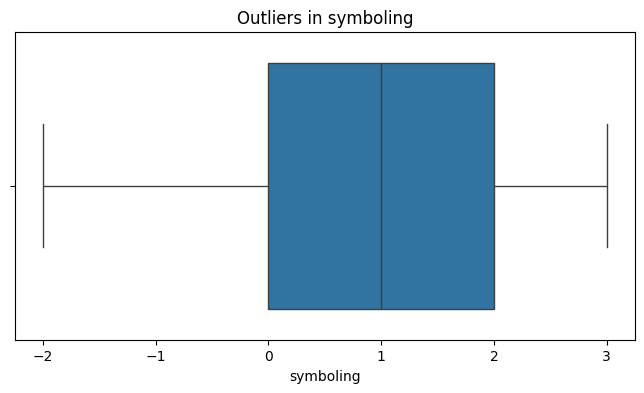

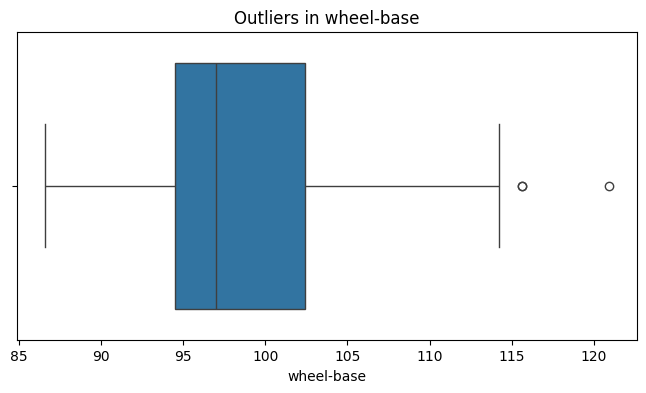

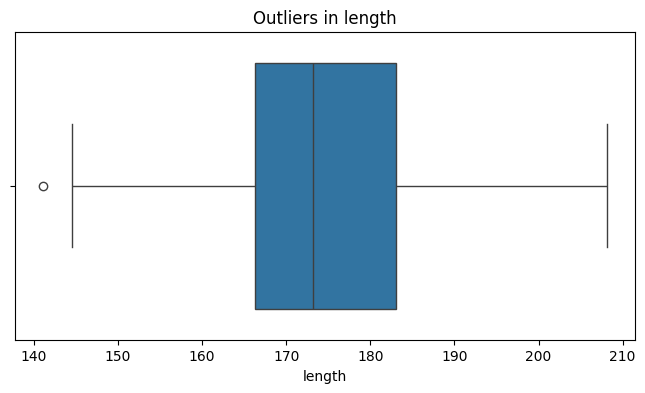

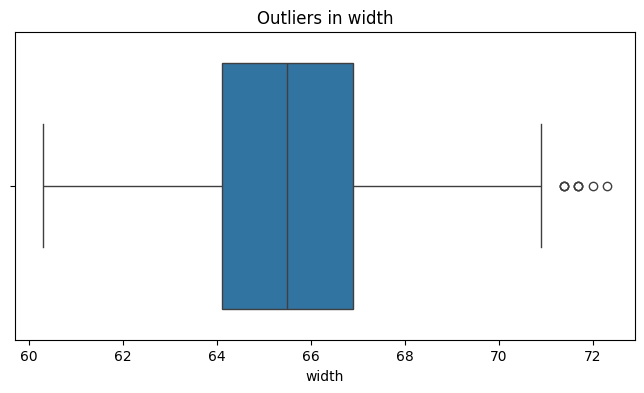

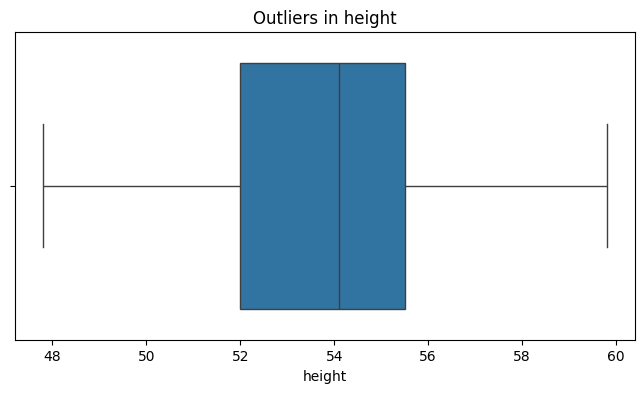

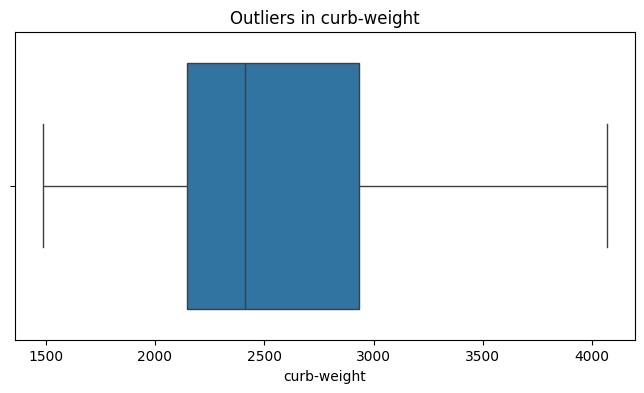

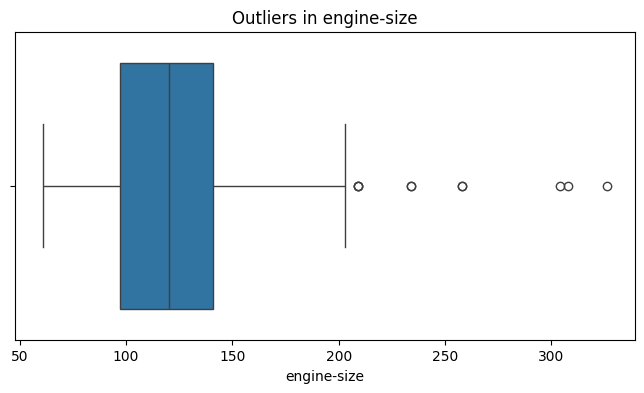

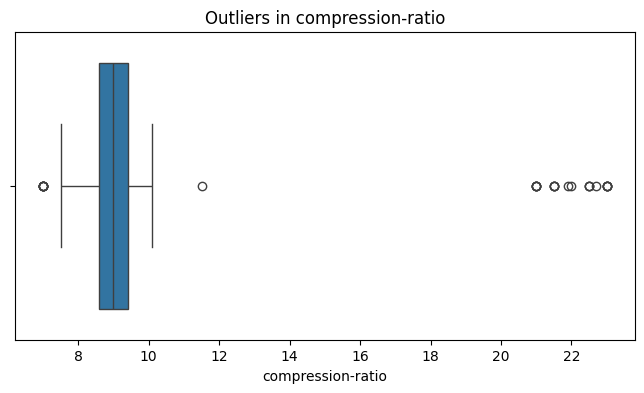

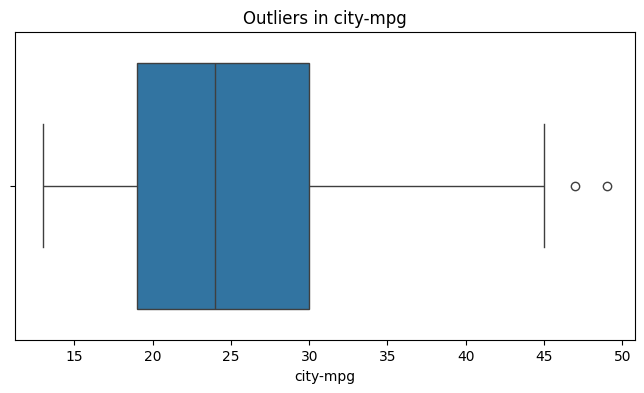

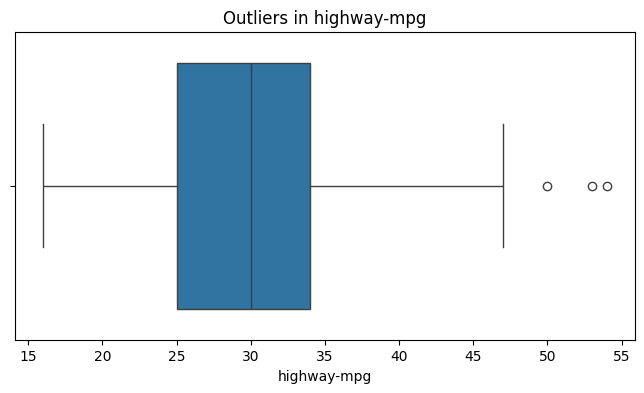

In [39]:
numerical_features = df.select_dtypes(include=['float64', 'int64']).columns
for feature in numerical_features:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[feature])
    plt.title(f"Outliers in {feature}")
    plt.show()

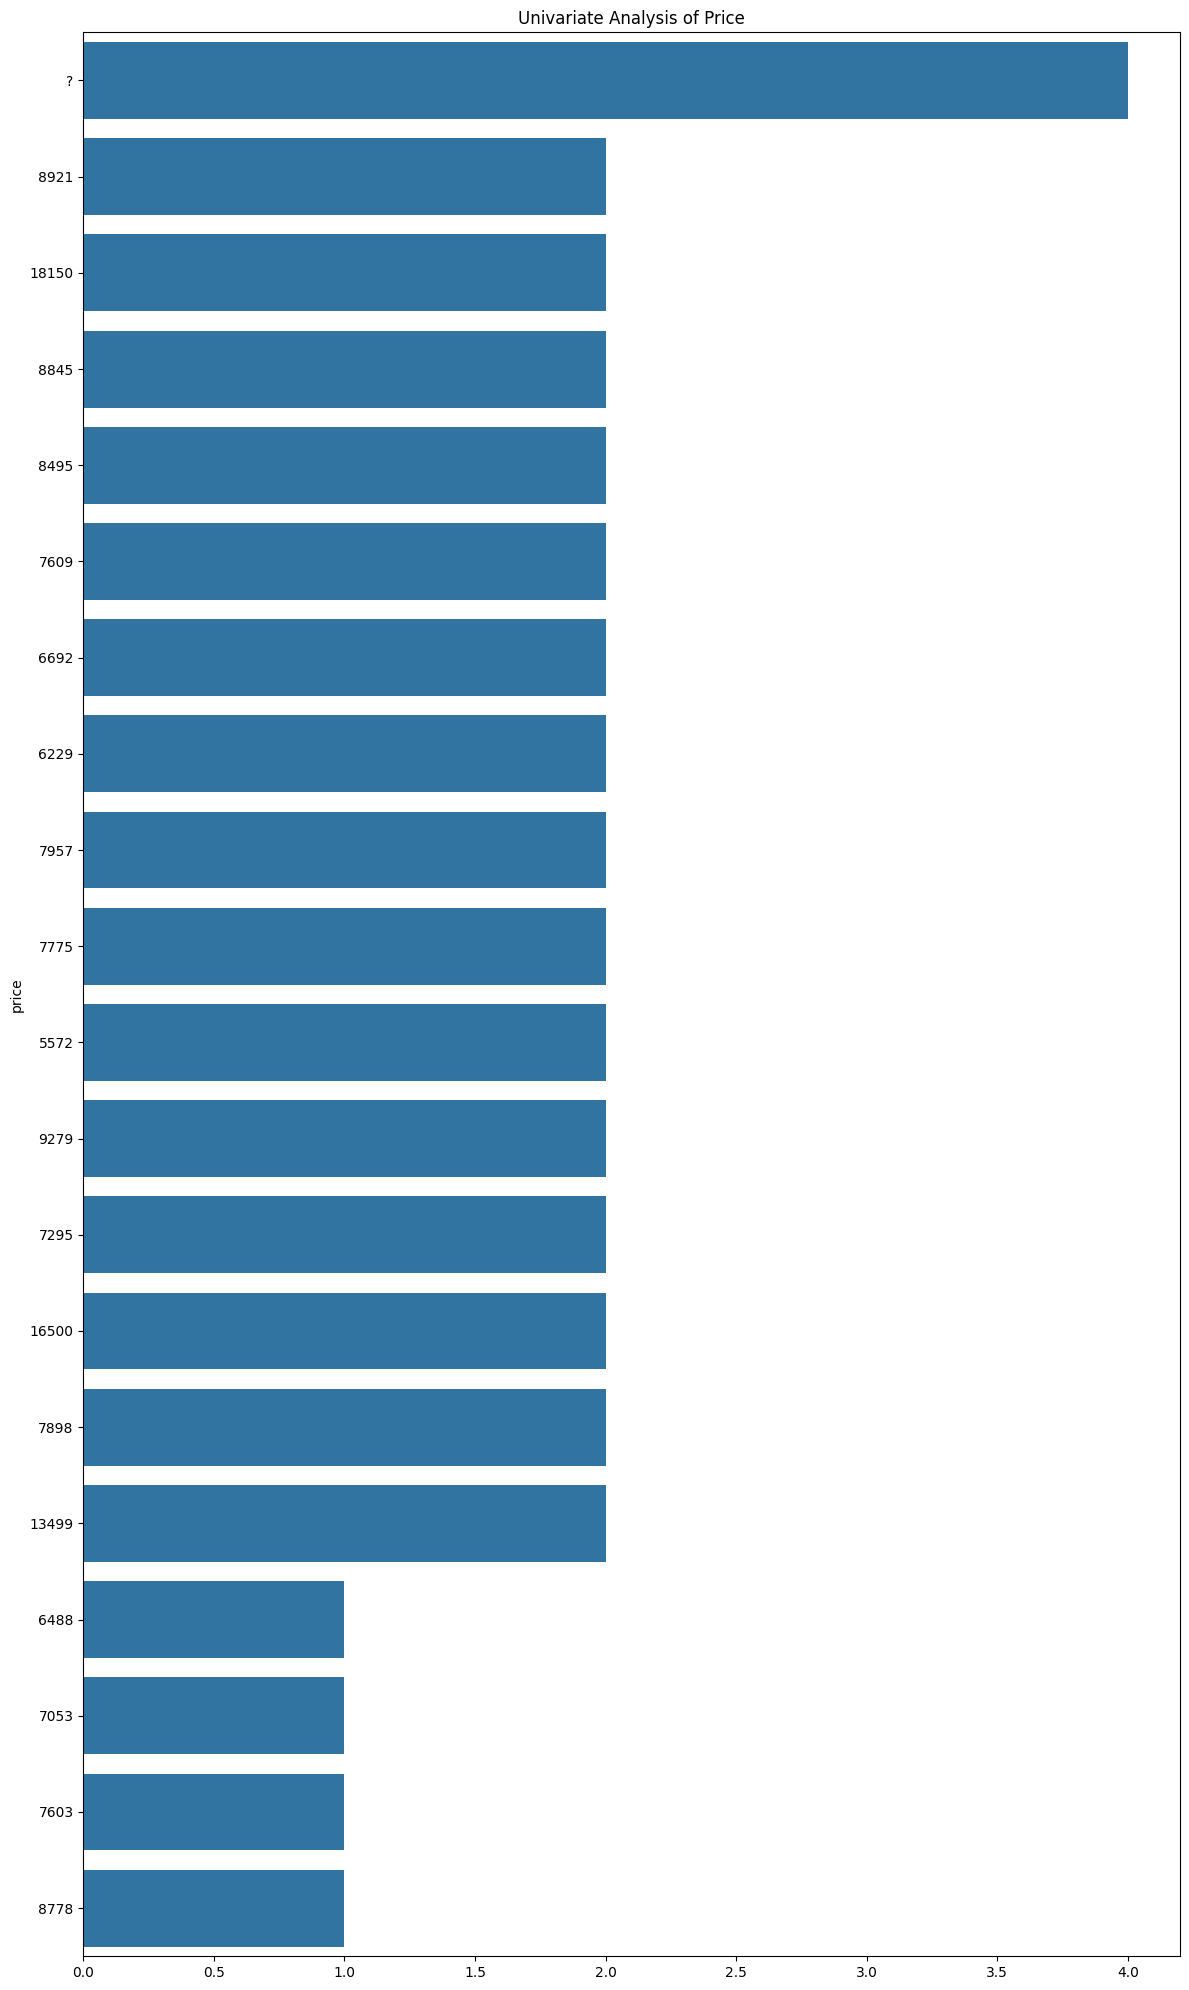

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 20))

# Sort and filter unique values (if necessary)
if df['price'].nunique() > 20:  # Show only the top 20 most frequent categories if there are too many
    top_values = df['price'].value_counts().head(20)
    sns.barplot(x=top_values.values, y=top_values.index, orient='h')
else:
    sns.countplot(data=df, y='price', order=df['price'].value_counts().index)

# Adjust spacing for better readability
plt.title("Univariate Analysis of Price")
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

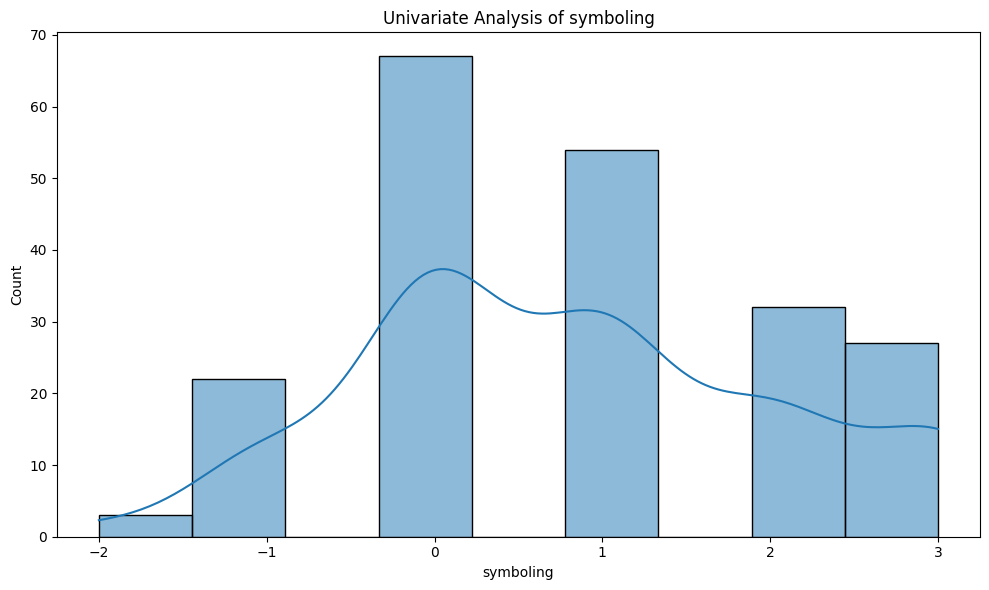

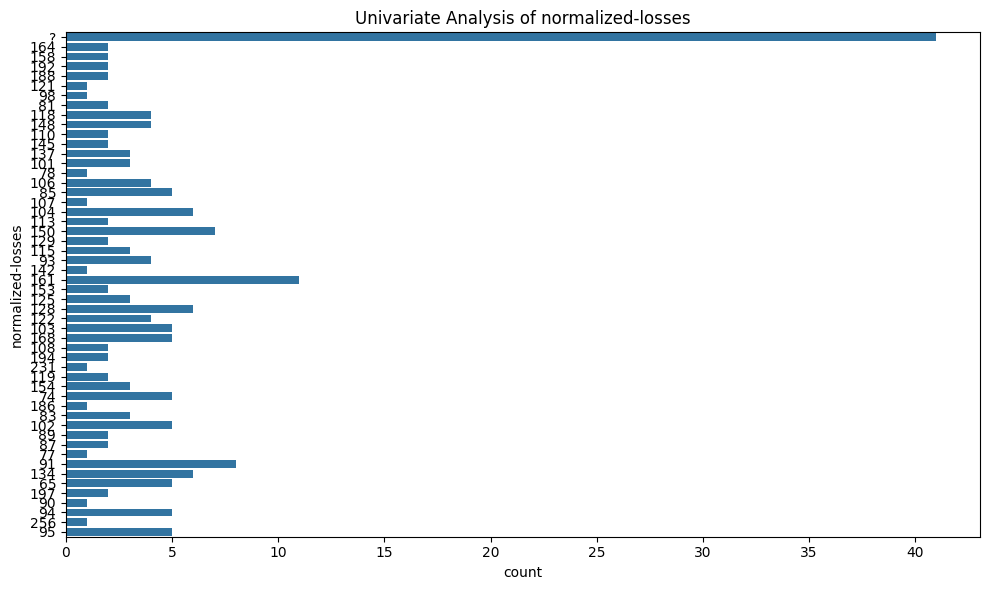

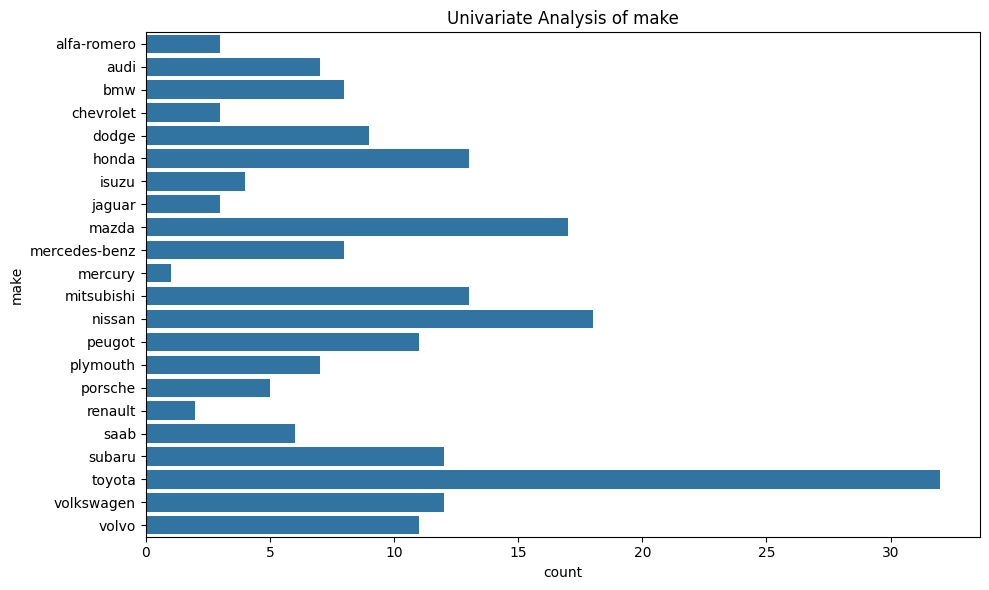

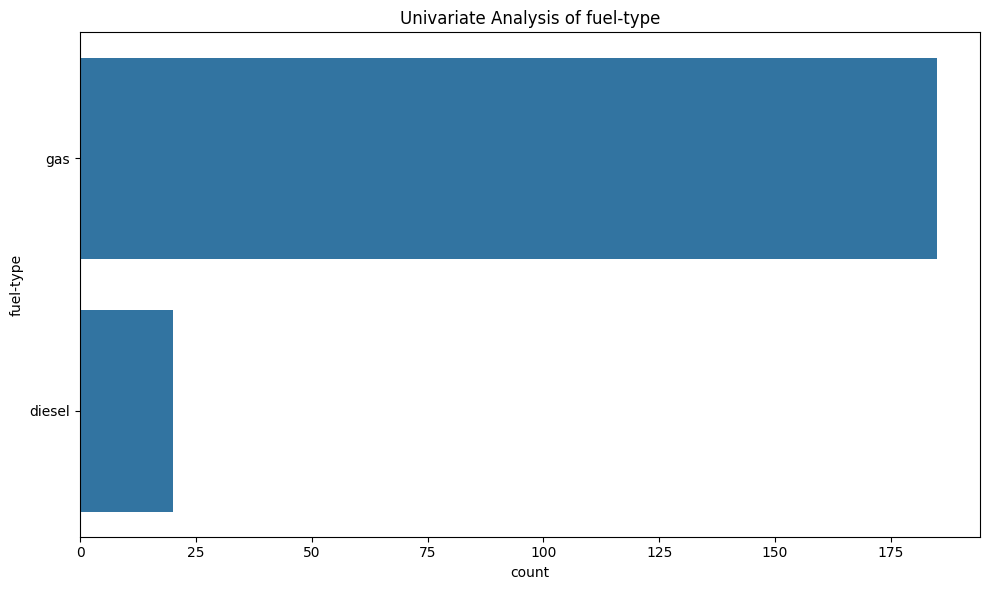

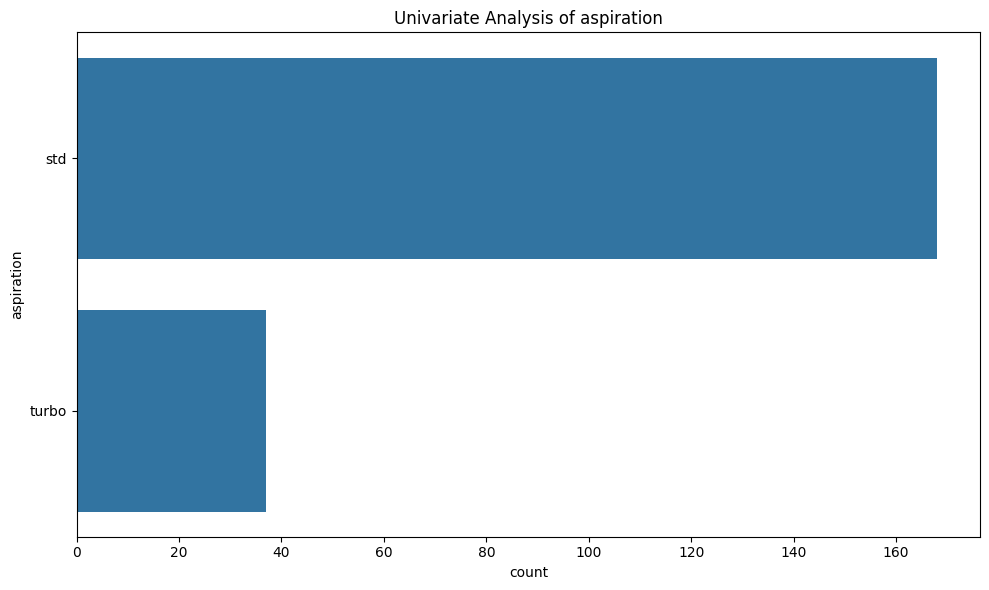

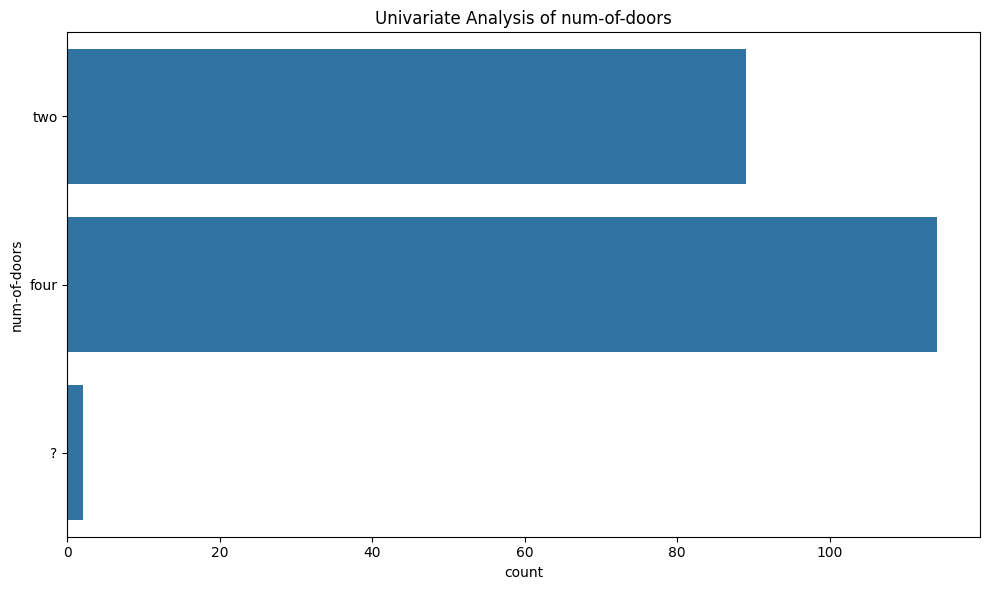

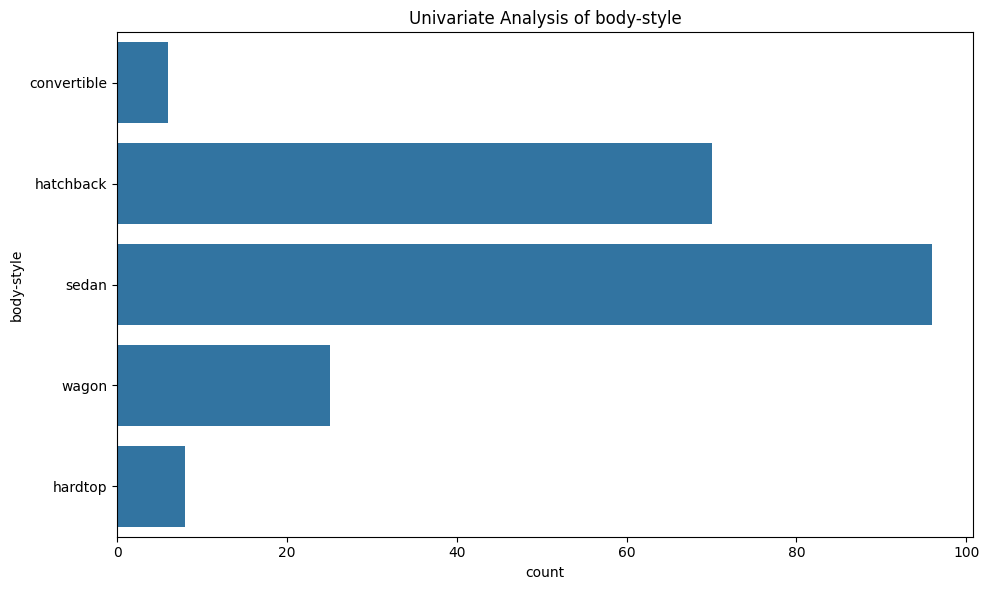

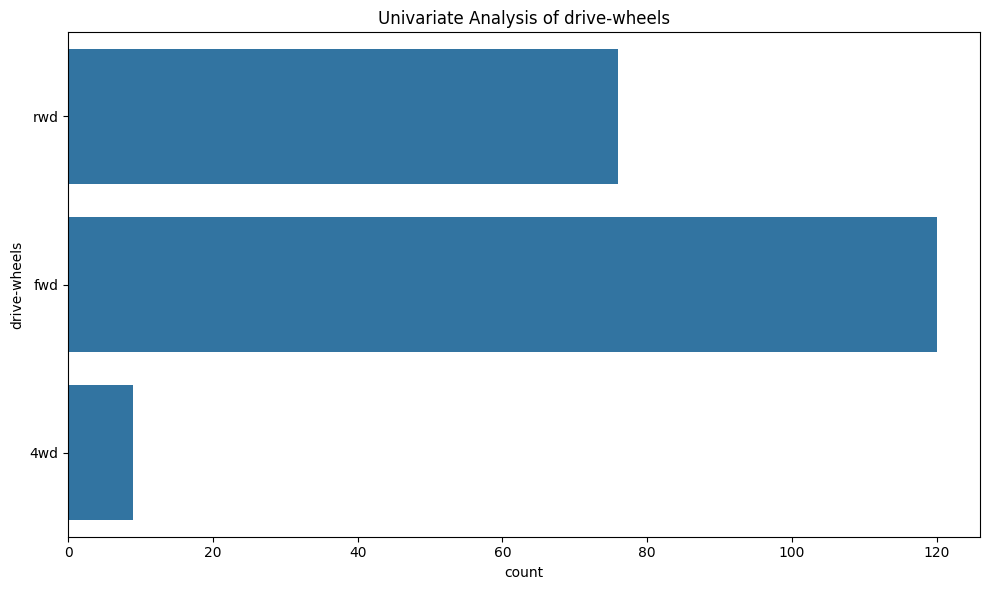

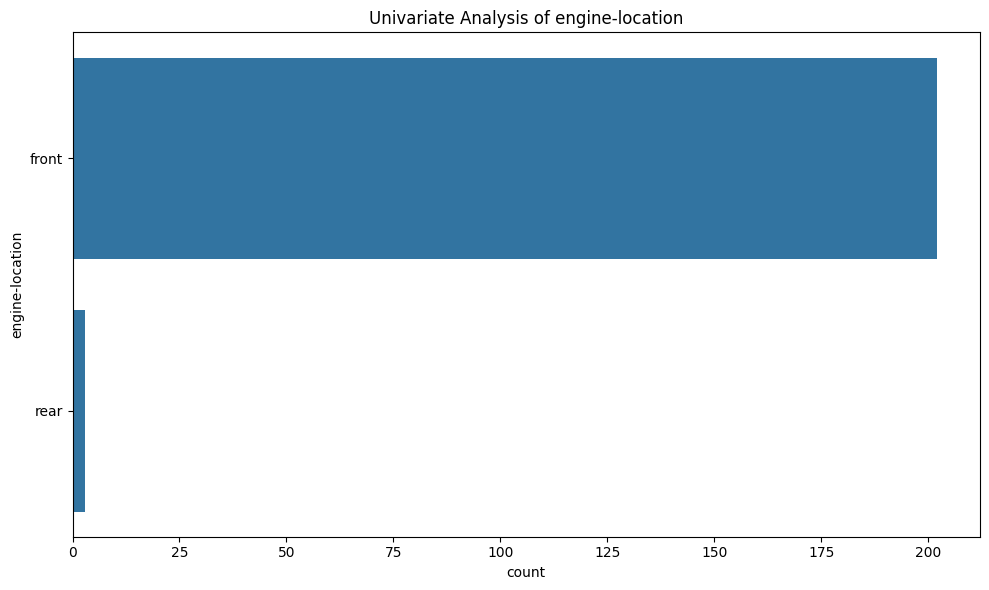

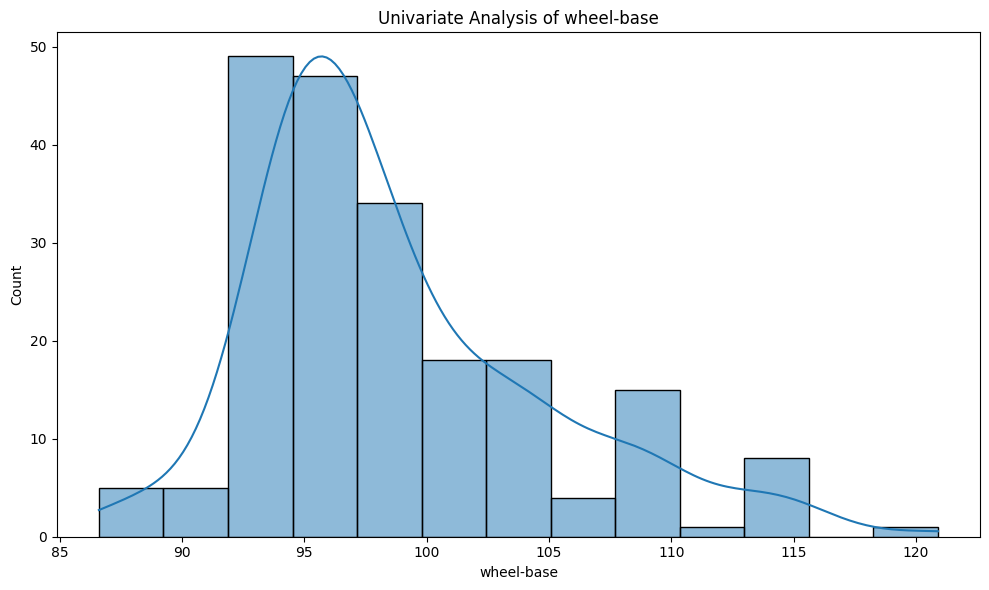

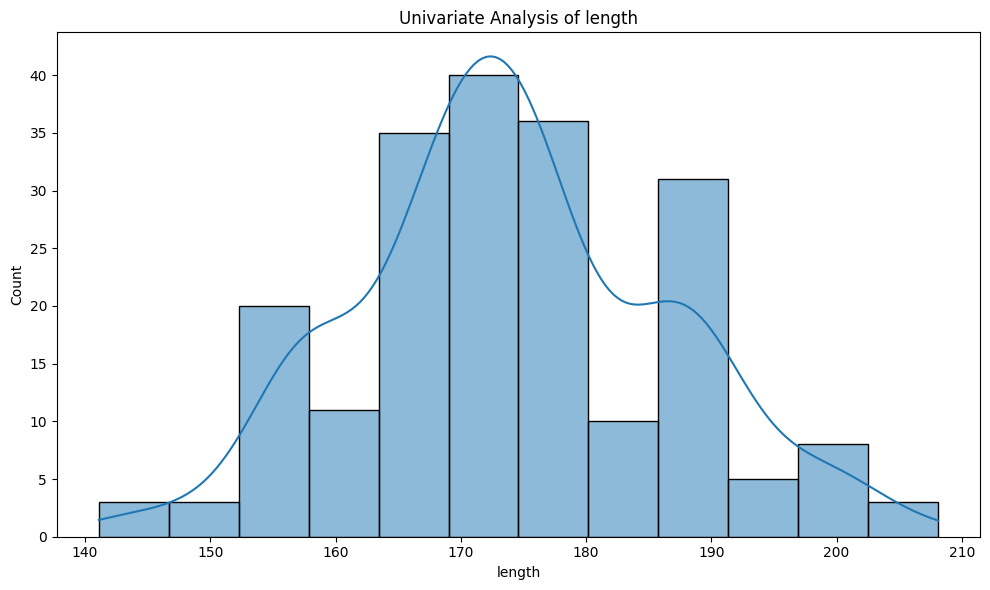

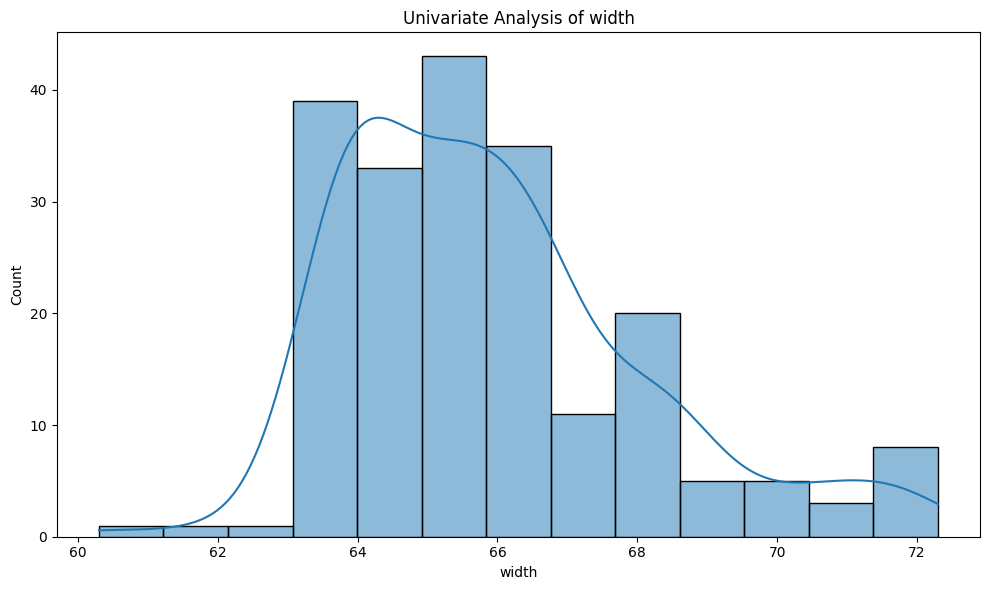

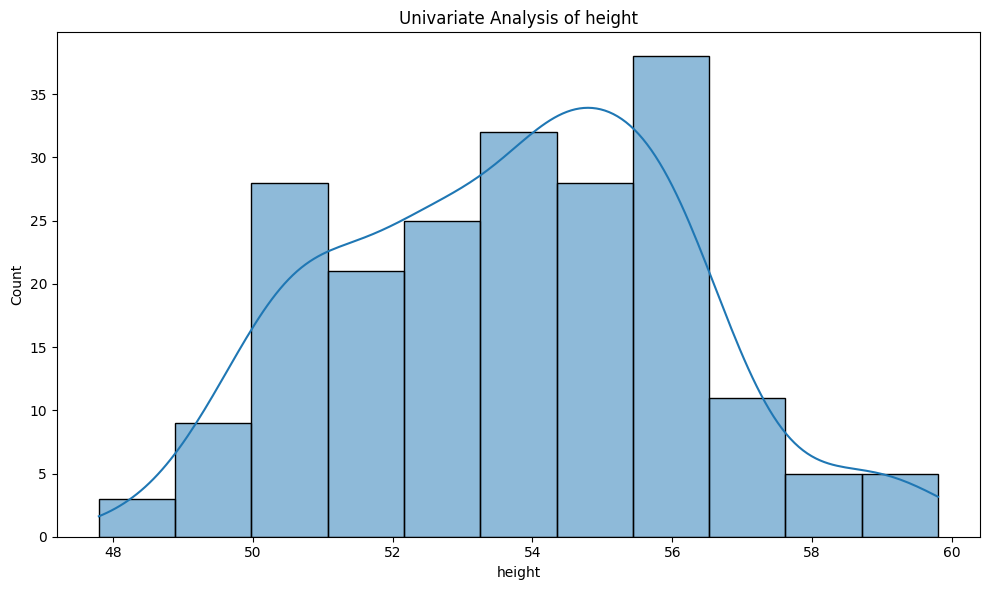

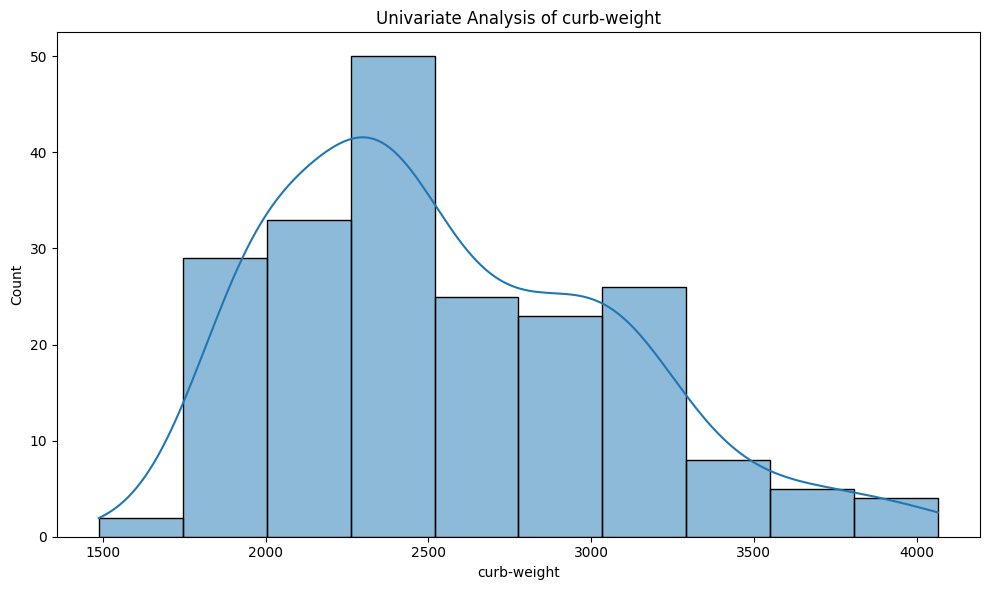

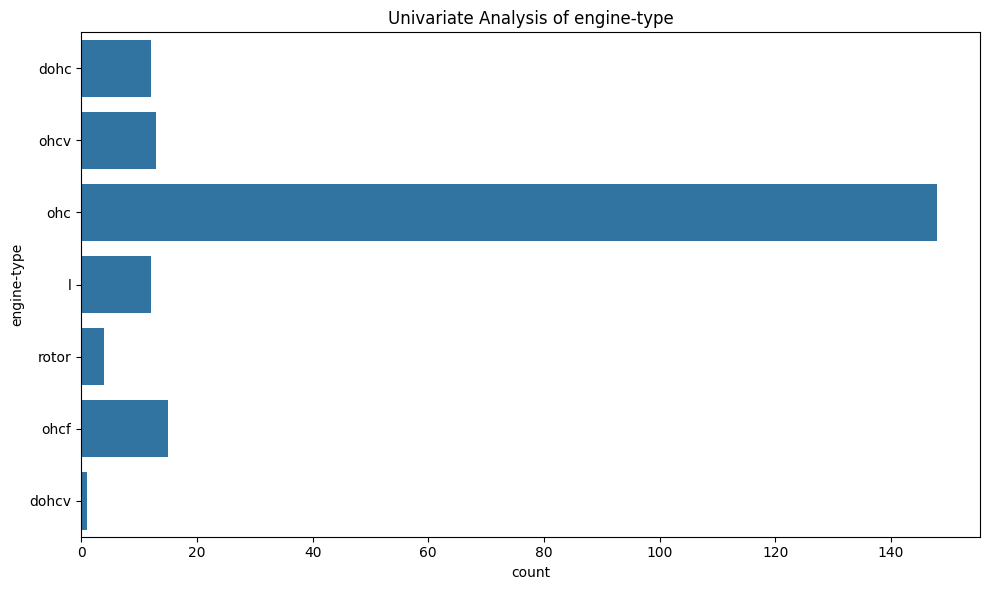

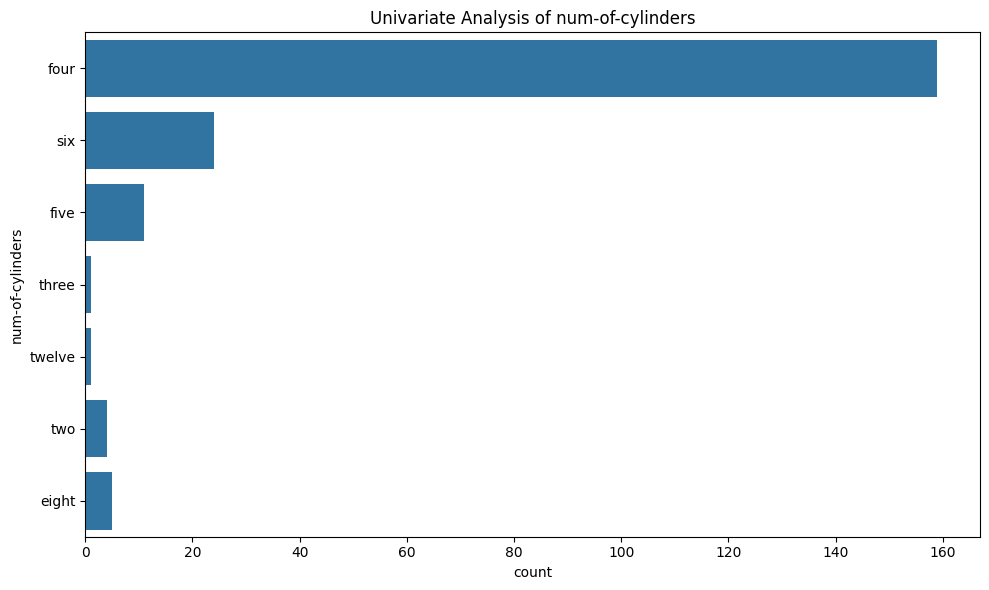

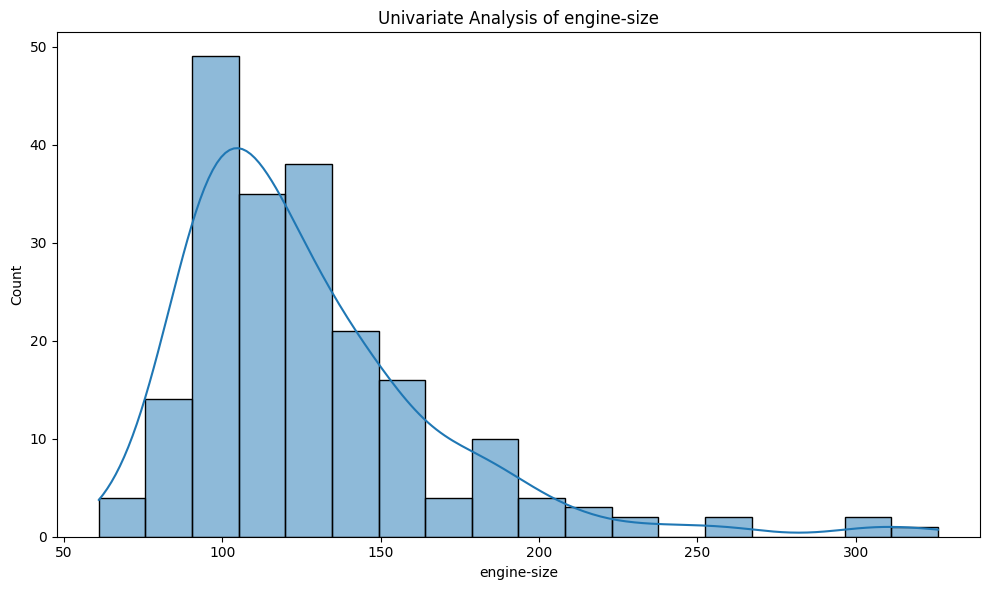

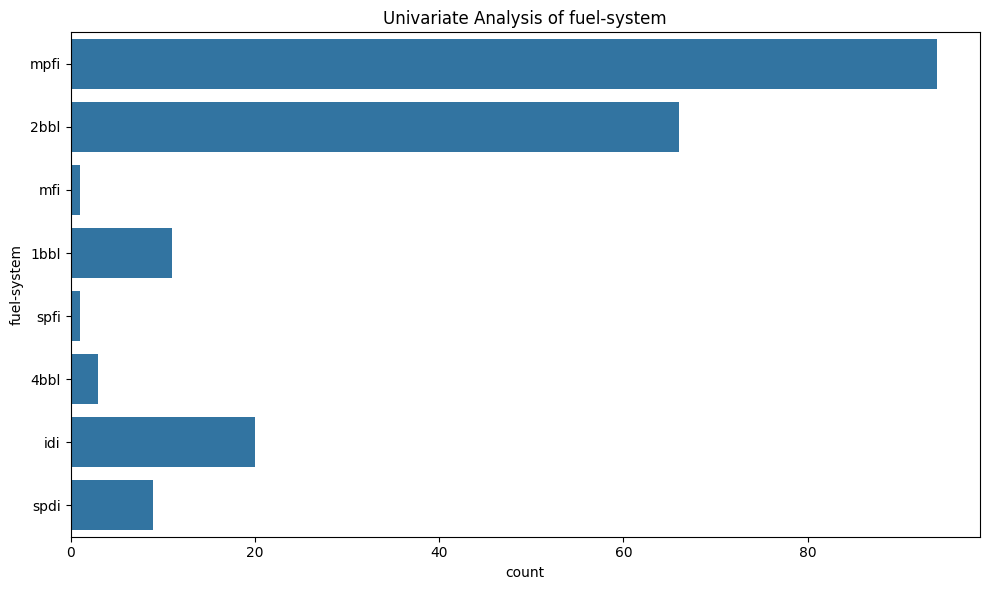

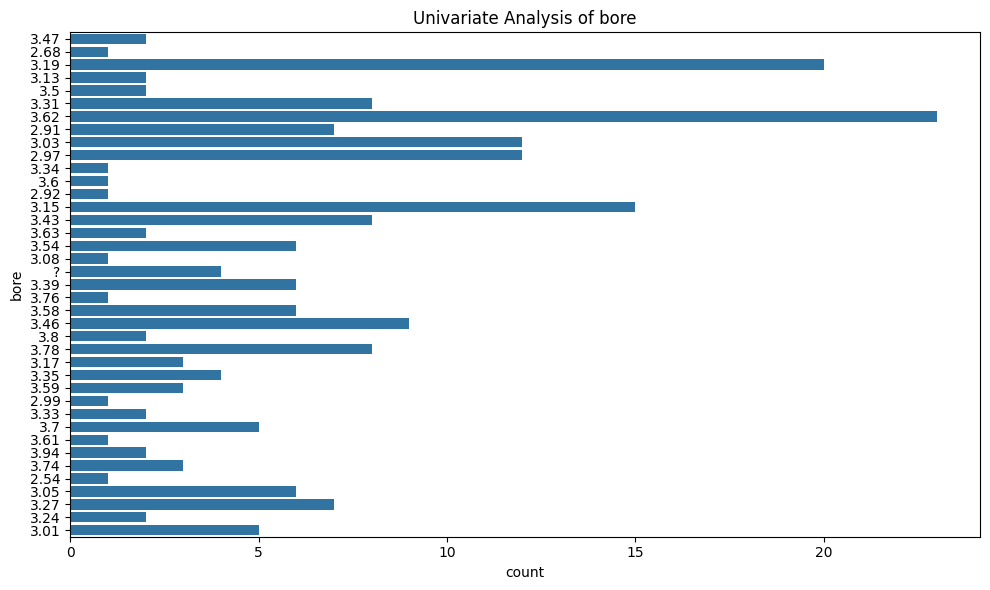

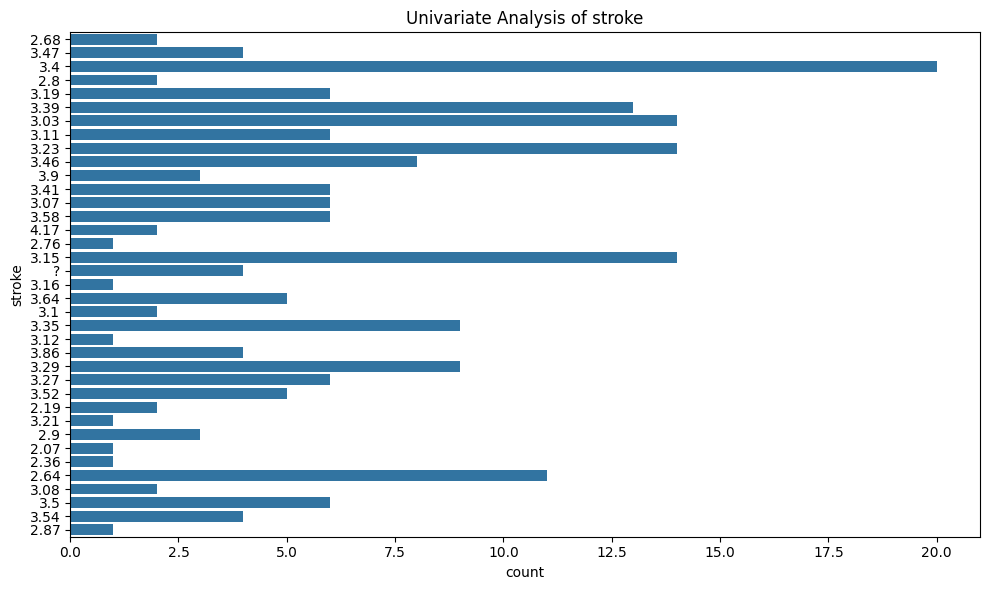

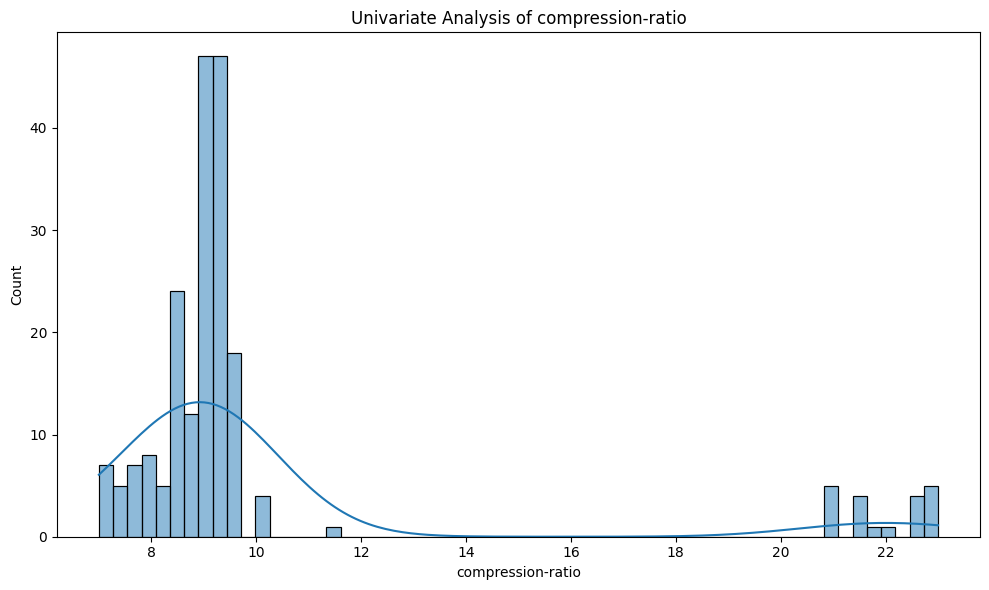

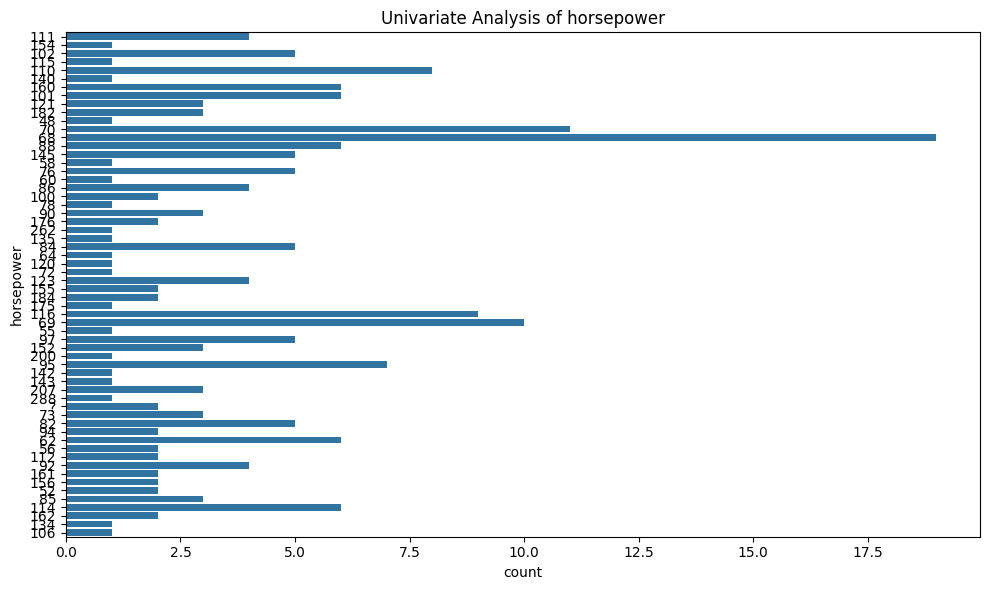

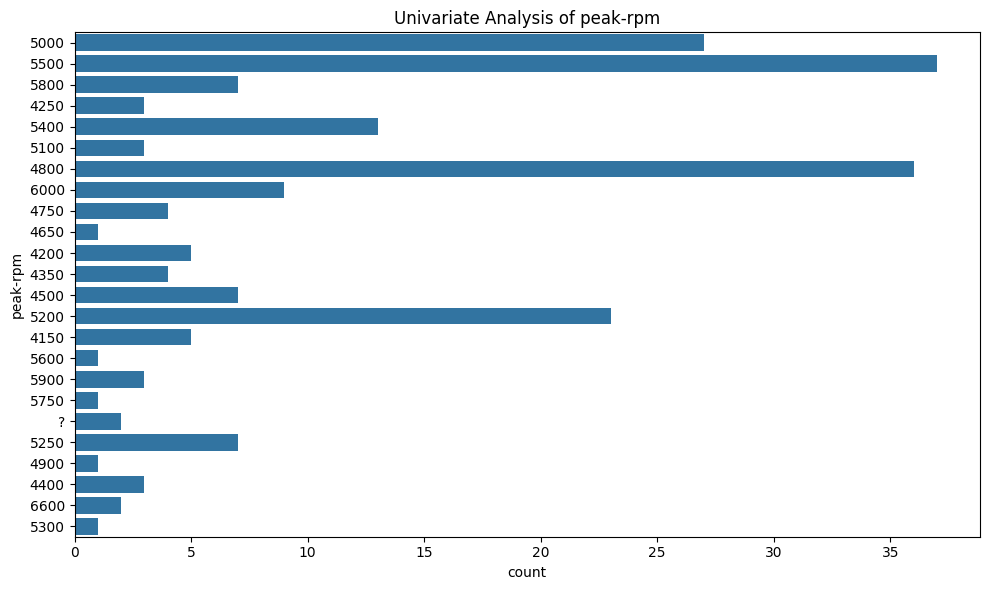

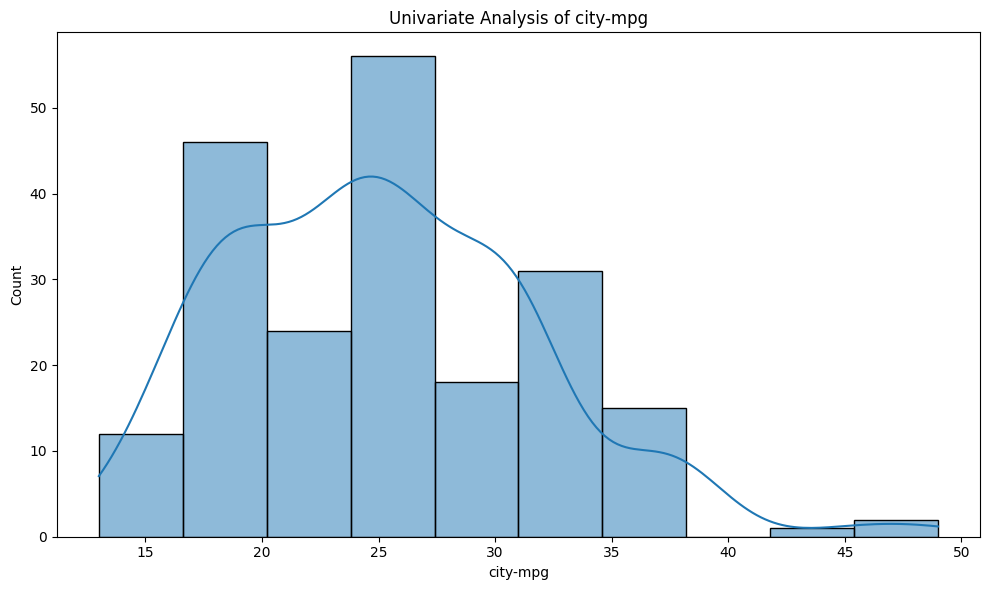

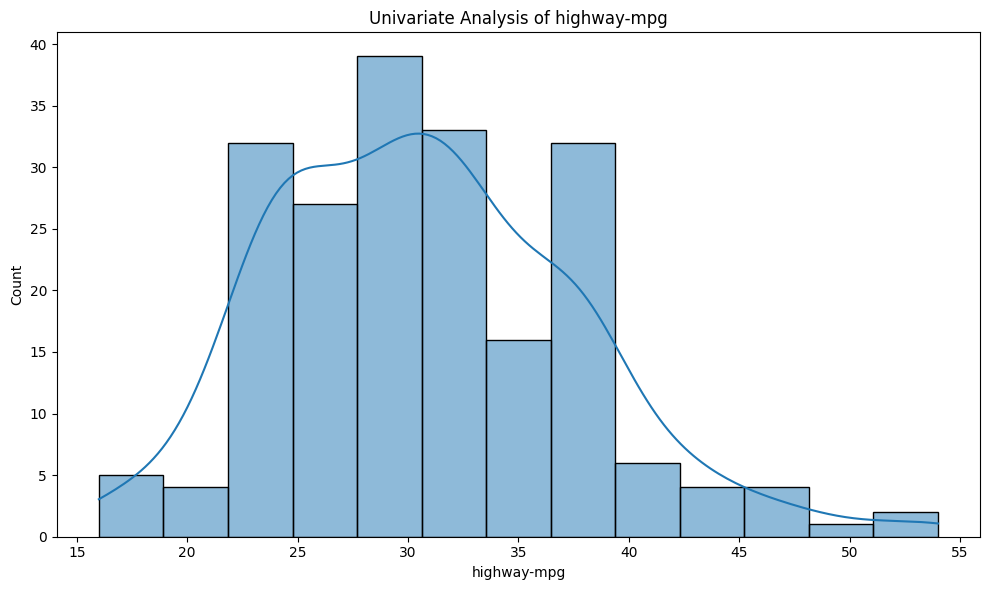

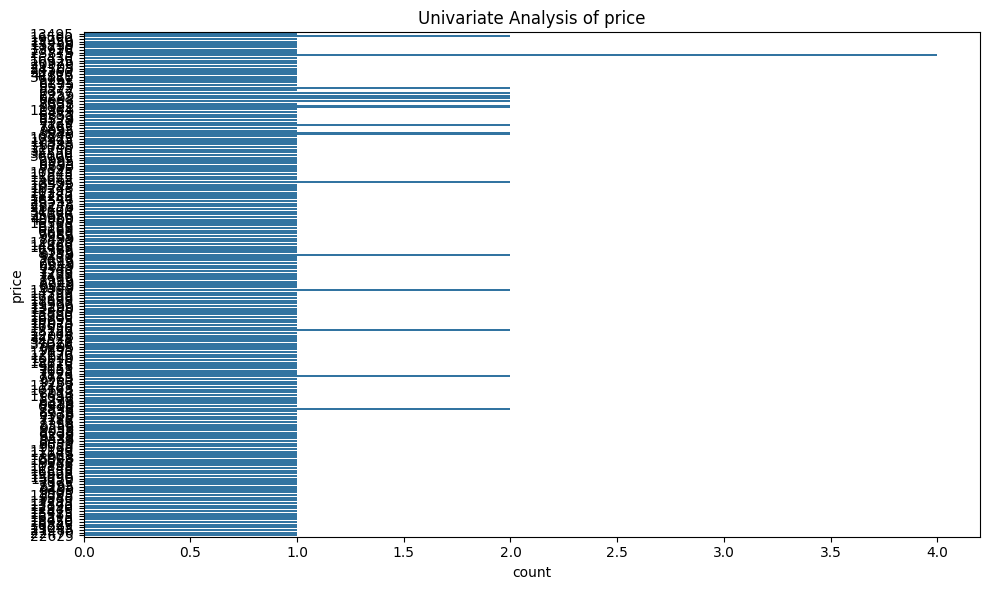

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a larger figure size for better visibility
plt.figure(figsize=(10, 6))

for col in df.columns:
    plt.figure(figsize=(10, 6))  # Set figure size for each plot
    if df[col].dtype == 'object':
        sns.countplot(data=df, y=col)
        plt.xticks(rotation=0)  # Rotate x-axis ticks if necessary
    else:
        sns.histplot(df[col], kde=True)
        plt.xticks(rotation=0)

    plt.title(f"Univariate Analysis of {col}")

    # Adjust spacing for better readability
    plt.tight_layout()
    plt.show()

In [97]:
import numpy as np
df = df.replace('?', np.nan)

In [98]:
# Convert numerical columns stored as objects to float
num_cols = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']
for col in num_cols:
    df[col] = pd.to_numeric(df[col])

# Fill missing values
for col in df.columns:
    if df[col].dtype == 'object':  # Categorical columns
        df[col] = df[col].fillna(df[col].mode()[0])
    else:  # Numerical columns
        df[col] = df[col].fillna(df[col].mean())

# Remove outliers using IQR
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
for feature in numerical_features:
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[feature] >= (Q1 - 1.5 * IQR)) & (df[feature] <= (Q3 + 1.5 * IQR))]

# Encode categorical variables
categorical_features = df.select_dtypes(include=['object']).columns

# Apply label encoding for ordinal features
ordinal_features = ['num-of-doors', 'num-of-cylinders']
ordinal_mapping = {
    'num-of-doors': {'two': 2, 'four': 4},
    'num-of-cylinders': {'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'eight': 8, 'twelve': 12}
}
for col in ordinal_features:
    df[col] = df[col].map(ordinal_mapping[col])

# Apply one-hot encoding for the remaining categorical variables
df = pd.get_dummies(df, columns=[col for col in categorical_features if col not in ordinal_features], drop_first=False)

# Ensure 'price' is a numeric column
df['price'] = df['price'].astype(float)

# Final shape
print(df.shape)
print(df.info())


(121, 58)
<class 'pandas.core.frame.DataFrame'>
Index: 121 entries, 0 to 202
Data columns (total 58 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   symboling               121 non-null    int64  
 1   normalized-losses       121 non-null    float64
 2   num-of-doors            121 non-null    int64  
 3   wheel-base              121 non-null    float64
 4   length                  121 non-null    float64
 5   width                   121 non-null    float64
 6   height                  121 non-null    float64
 7   curb-weight             121 non-null    int64  
 8   num-of-cylinders        121 non-null    int64  
 9   engine-size             121 non-null    int64  
 10  bore                    121 non-null    float64
 11  stroke                  121 non-null    float64
 12  compression-ratio       121 non-null    float64
 13  horsepower              121 non-null    float64
 14  peak-rpm                121 non-null 

In [99]:
print(df.dtypes)

symboling                   int64
normalized-losses         float64
num-of-doors                int64
wheel-base                float64
length                    float64
width                     float64
height                    float64
curb-weight                 int64
num-of-cylinders            int64
engine-size                 int64
bore                      float64
stroke                    float64
compression-ratio         float64
horsepower                float64
peak-rpm                  float64
city-mpg                    int64
highway-mpg                 int64
price                     float64
make_alfa-romero             bool
make_audi                    bool
make_bmw                     bool
make_chevrolet               bool
make_dodge                   bool
make_honda                   bool
make_isuzu                   bool
make_mazda                   bool
make_mercury                 bool
make_mitsubishi              bool
make_nissan                  bool
make_peugot   

In [100]:
df

,symboling,normalized-losses,num-of-doors,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,...,engine-type_dohc,engine-type_l,engine-type_ohc,engine-type_ohcv,engine-type_rotor,fuel-system_1bbl,fuel-system_2bbl,fuel-system_4bbl,fuel-system_mpfi,fuel-system_spfi
0,3,122.0,2,88.6,168.8,64.1,48.8,2548,4,130,...,True,False,False,False,False,False,False,False,True,False
1,3,122.0,2,88.6,168.8,64.1,48.8,2548,4,130,...,True,False,False,False,False,False,False,False,True,False
2,1,122.0,2,94.5,171.2,65.5,52.4,2823,6,152,...,False,False,False,True,False,False,False,False,True,False
3,2,164.0,4,99.8,176.6,66.2,54.3,2337,4,109,...,False,False,True,False,False,False,False,False,True,False
4,2,164.0,4,99.4,176.6,66.4,54.3,2824,5,136,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,-2,103.0,4,104.3,188.8,67.2,56.2,2935,4,141,...,False,False,True,False,False,False,False,False,True,False
197,-1,74.0,4,104.3,188.8,67.2,57.5,3042,4,141,...,False,False,True,False,False,False,False,False,True,False
200,-1,95.0,4,109.1,188.8,68.9,55.5,2952,4,141,...,False,False,True,False,False,False,False,False,True,False
201,-1,95.0,4,109.1,188.8,68.8,55.5,3049,4,141,...,False,False,True,False,False,False,False,False,True,False


In [101]:
df.corr()

,symboling,normalized-losses,num-of-doors,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,...,engine-type_dohc,engine-type_l,engine-type_ohc,engine-type_ohcv,engine-type_rotor,fuel-system_1bbl,fuel-system_2bbl,fuel-system_4bbl,fuel-system_mpfi,fuel-system_spfi
symboling,1.000000,0.533095,-0.605113,-0.541424,-0.304570,-0.195488,-0.523342,-0.233196,-0.367183,-0.275326,...,0.132964,-0.111380,-0.124377,-0.145026,0.344425,-0.081537,-0.051402,0.297014,-0.013027,0.092108
normalized-losses,0.533095,1.000000,-0.386144,-0.164125,-0.063017,0.013161,-0.445941,0.017584,-0.012187,0.018987,...,0.002979,0.170478,-0.158409,-0.042624,0.210856,-0.181298,0.017614,0.181831,0.023693,0.013107
num-of-doors,-0.605113,-0.386144,1.000000,0.402536,0.376090,0.182042,0.476801,0.246960,0.215378,0.169230,...,-0.032413,0.138419,0.012407,0.096355,-0.212990,-0.103224,0.016584,-0.183672,0.118242,-0.105156
wheel-base,-0.541424,-0.164125,0.402536,1.000000,0.816764,0.800244,0.586154,0.750708,0.287227,0.612622,...,-0.004397,0.451245,-0.239839,0.163140,-0.091365,-0.191074,-0.453970,-0.078788,0.597554,-0.030658
length,-0.304570,-0.063017,0.376090,0.816764,1.000000,0.796120,0.498307,0.874572,0.282148,0.719022,...,0.217681,0.299354,-0.368290,0.219884,-0.036423,-0.313996,-0.495799,-0.031409,0.685641,0.013337
width,-0.195488,0.013161,0.182042,0.800244,0.796120,1.000000,0.300822,0.772450,0.165127,0.632590,...,0.077944,0.350178,-0.358052,0.224891,0.063095,-0.208953,-0.590217,0.054410,0.698006,-0.000207
height,-0.523342,-0.445941,0.476801,0.586154,0.498307,0.300822,1.000000,0.399517,0.255548,0.269135,...,-0.072075,0.242457,0.046948,0.095120,-0.322689,-0.016459,-0.139054,-0.278270,0.254625,-0.090221
curb-weight,-0.233196,0.017584,0.246960,0.750708,0.874572,0.772450,0.399517,1.000000,0.377084,0.806352,...,0.269741,0.297979,-0.504934,0.360895,0.016551,-0.227911,-0.626152,0.002232,0.746144,0.083375
num-of-cylinders,-0.367183,-0.012187,0.215378,0.287227,0.282148,0.165127,0.255548,0.377084,1.000000,0.701577,...,0.191917,-0.025738,-0.141880,0.590341,-0.585449,-0.048450,-0.152336,-0.504860,0.343651,-0.014735
engine-size,-0.275326,0.018987,0.169230,0.612622,0.719022,0.632590,0.269135,0.806352,0.701577,1.000000,...,0.231884,0.040057,-0.284314,0.499601,-0.306691,-0.191312,-0.521170,-0.280502,0.720328,0.019263


In [102]:
print(df.dtypes)

symboling                   int64
normalized-losses         float64
num-of-doors                int64
wheel-base                float64
length                    float64
width                     float64
height                    float64
curb-weight                 int64
num-of-cylinders            int64
engine-size                 int64
bore                      float64
stroke                    float64
compression-ratio         float64
horsepower                float64
peak-rpm                  float64
city-mpg                    int64
highway-mpg                 int64
price                     float64
make_alfa-romero             bool
make_audi                    bool
make_bmw                     bool
make_chevrolet               bool
make_dodge                   bool
make_honda                   bool
make_isuzu                   bool
make_mazda                   bool
make_mercury                 bool
make_mitsubishi              bool
make_nissan                  bool
make_peugot   

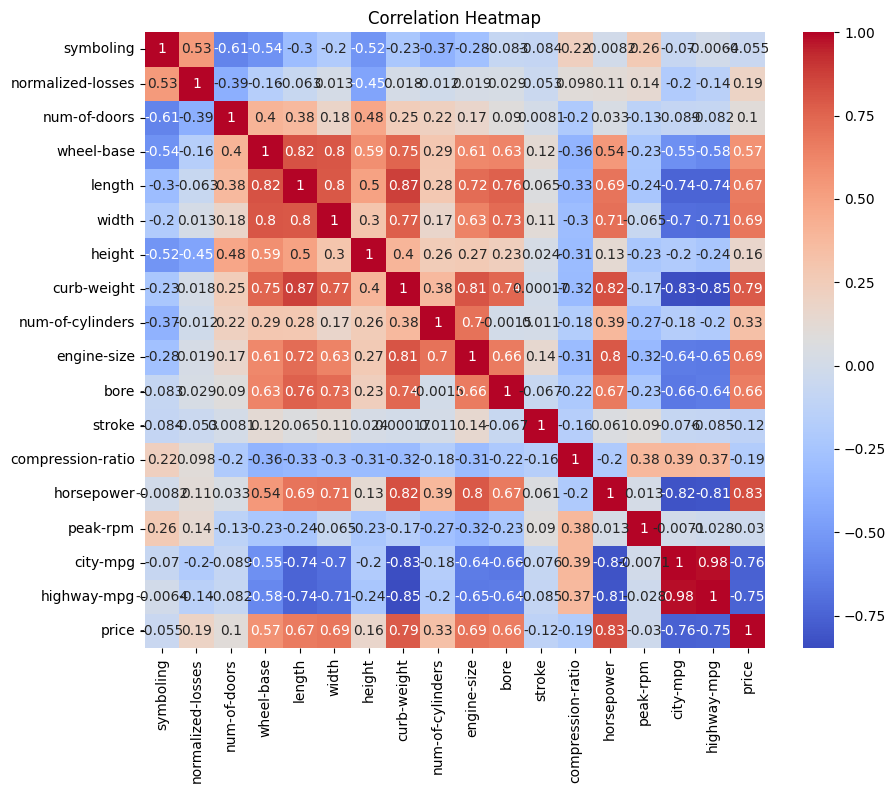

In [103]:
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except ValueError:
        pass

# Filter out non-numeric columns before calculating correlation
numerical_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10, 8))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

<Axes: xlabel='horsepower', ylabel='price'>

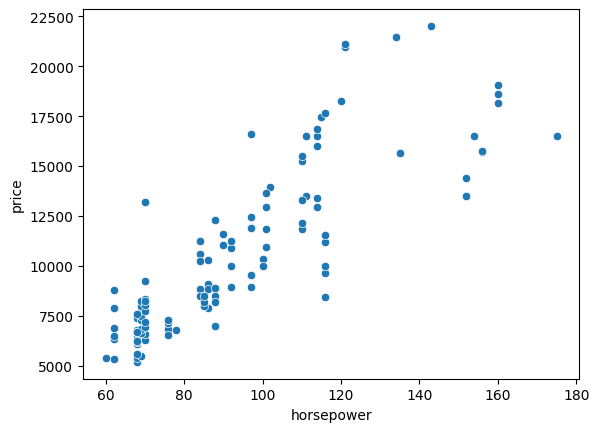

In [104]:
import seaborn as sns
sns.scatterplot(x=df['horsepower'], y=df['price'])

<Axes: xlabel='curb-weight', ylabel='price'>

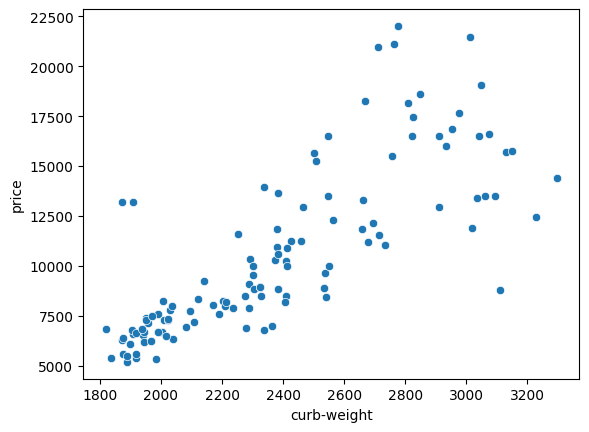

In [105]:
sns.scatterplot(x=df['curb-weight'], y=df['price'])

<Axes: xlabel='engine-size', ylabel='price'>

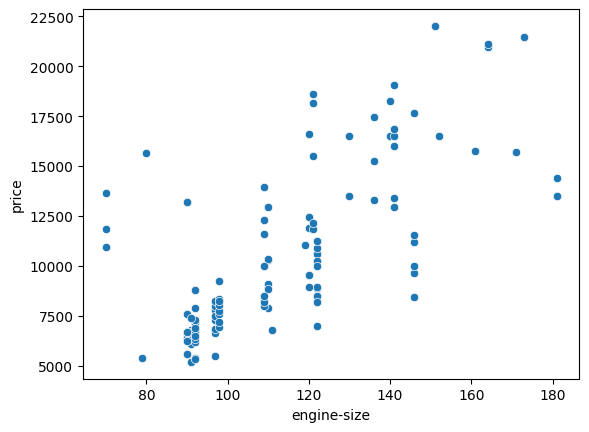

In [106]:
sns.scatterplot(x=df['engine-size'], y=df['price'])

In [107]:
X = df.iloc[:, df.columns != 'price']  # Select all columns except 'price'
y = df.iloc[:, df.columns == 'price']   # Select only the 'price' column

In [108]:
X.head(5)

,symboling,normalized-losses,num-of-doors,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,...,engine-type_dohc,engine-type_l,engine-type_ohc,engine-type_ohcv,engine-type_rotor,fuel-system_1bbl,fuel-system_2bbl,fuel-system_4bbl,fuel-system_mpfi,fuel-system_spfi
0,3,122.0,2,88.6,168.8,64.1,48.8,2548,4,130,...,True,False,False,False,False,False,False,False,True,False
1,3,122.0,2,88.6,168.8,64.1,48.8,2548,4,130,...,True,False,False,False,False,False,False,False,True,False
2,1,122.0,2,94.5,171.2,65.5,52.4,2823,6,152,...,False,False,False,True,False,False,False,False,True,False
3,2,164.0,4,99.8,176.6,66.2,54.3,2337,4,109,...,False,False,True,False,False,False,False,False,True,False
4,2,164.0,4,99.4,176.6,66.4,54.3,2824,5,136,...,False,False,True,False,False,False,False,False,True,False


In [109]:
y.head(5)

,price
0,13495.0
1,16500.0
2,16500.0
3,13950.0
4,17450.0


In [110]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select only numeric columns
X = df.select_dtypes(include=[np.number])

# Drop rows with NaN or infinite values
X = X.replace([np.inf, -np.inf], np.nan).dropna()

# Calculate VIF
vif = pd.DataFrame()
vif["variables"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)


            variables          VIF
0           symboling     5.608411
1   normalized-losses    41.425612
2        num-of-doors    24.516568
3          wheel-base  3582.454981
4              length  2291.890241
5               width  6376.386881
6              height  1463.272389
7         curb-weight   462.940475
8    num-of-cylinders   874.872423
9         engine-size  1128.845511
10               bore  3501.916715
11             stroke   842.449626
12  compression-ratio   881.237550
13         horsepower   101.259509
14           peak-rpm   330.987199
15           city-mpg   943.010819
16        highway-mpg  1165.209944
17              price    34.441160


In [111]:
print(df.dtypes)

symboling                   int64
normalized-losses         float64
num-of-doors                int64
wheel-base                float64
length                    float64
width                     float64
height                    float64
curb-weight                 int64
num-of-cylinders            int64
engine-size                 int64
bore                      float64
stroke                    float64
compression-ratio         float64
horsepower                float64
peak-rpm                  float64
city-mpg                    int64
highway-mpg                 int64
price                     float64
make_alfa-romero             bool
make_audi                    bool
make_bmw                     bool
make_chevrolet               bool
make_dodge                   bool
make_honda                   bool
make_isuzu                   bool
make_mazda                   bool
make_mercury                 bool
make_mitsubishi              bool
make_nissan                  bool
make_peugot   

In [59]:
!pip install statsmodels
import statsmodels.stats.stattools as st

In [112]:
new_df = df  # Assuming df is your cleaned dataset
for column in new_df.columns:
    print(column, " ", st.durbin_watson(new_df[column]))


symboling   0.4939271255060729
normalized-losses   0.05340593727765557
num-of-doors   0.13109756097560976
wheel-base   0.0012411050801925162
length   0.002176828148010234
width   0.0002787339409342071
height   0.0019687022113575986
curb-weight   0.018679944717594044
num-of-cylinders   0.02100238663484487
engine-size   0.026913928825267018
bore   0.003632521178860191
stroke   0.0015491691653014674
compression-ratio   0.002491978696850357
horsepower   0.06408014723228225
peak-rpm   0.003625541782509986
city-mpg   0.035447272892793334
highway-mpg   0.023690493667854026
price   0.10029531052035304
make_alfa-romero   0.3333333333333333
make_audi   0.6666666666666666
make_bmw   1.0
make_chevrolet   1.0
make_dodge   0.3333333333333333
make_honda   0.16666666666666666
make_isuzu   0.5
make_mazda   0.13333333333333333
make_mercury   2.0
make_mitsubishi   0.3333333333333333
make_nissan   0.14285714285714285
make_peugot   0.6666666666666666
make_plymouth   0.4
make_porsche   2.0
make_saab   0.4
m

In [113]:
st.durbin_watson(y)

array([0.10029531])

In [139]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1000)

In [140]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(96, 18)
(25, 18)
(96, 1)
(25, 1)


In [141]:
X_train.head()

,symboling,normalized-losses,num-of-doors,wheel-base,length,width,height,curb-weight,num-of-cylinders,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
163,1,168.0,2,94.5,168.7,64.0,52.6,2169,4,98,3.19,3.03,9.0,70.0,4800.0,29,34,8058.0
93,1,103.0,4,94.5,170.2,63.8,53.5,2024,4,97,3.15,3.29,9.4,69.0,5200.0,31,37,7349.0
202,-1,95.0,4,109.1,188.8,68.9,55.5,3012,6,173,3.58,2.87,8.8,134.0,5500.0,18,23,21485.0
99,0,106.0,4,97.2,173.4,65.2,54.7,2324,4,120,3.33,3.47,8.5,97.0,5200.0,27,34,8949.0
62,0,115.0,4,98.8,177.8,66.5,55.5,2410,4,122,3.39,3.39,8.6,84.0,4800.0,26,32,10245.0


In [142]:
# Trying to call linear regression model
from sklearn import linear_model
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [151]:
# before using decision tree lets use linear regression
model= linear_model.LinearRegression()
# model= DecisionTreeRegressor()
model.fit(X_train, y_train)

LinearRegression()

In [153]:
print('Coefficients', model.coef_)
print('Intercept', model.intercept_)

Coefficients [[-4.61610019e-13  3.88578059e-14  7.21295814e-14 -5.68189926e-14
   3.42760548e-14  2.02373607e-13  7.90399935e-14 -1.06877668e-15
   3.99323778e-13  2.69348187e-15 -1.03670404e-13 -1.67026878e-12
  -5.67778885e-13  4.56675531e-14  6.33507793e-17 -2.71544246e-14
   1.15136130e-13  1.00000000e+00]]
Intercept [-2.00088834e-11]


In [154]:
y_pred = model.predict(X_test)

In [155]:
y_pred_tr = model.predict(X_train)

In [156]:
y_pred

array([[16630.],
       [ 8195.],
       [13645.],
       [13499.],
       [ 6692.],
       [ 9988.],
       [15750.],
       [ 7609.],
       [ 8249.],
       [16515.],
       [16845.],
       [10945.],
       [18620.],
       [ 5389.],
       [ 6795.],
       [13950.],
       [ 9995.],
       [11845.],
       [17450.],
       [ 6095.],
       [ 6649.],
       [ 7738.],
       [ 7895.],
       [ 8495.],
       [ 8189.]])

In [157]:
from sklearn.metrics import mean_squared_error, r2_score
print('MSE', mean_squared_error(y_test, y_pred))
print('R2 score', r2_score(y_test, y_pred))

MSE 9.694556779121485e-24
R2 score 1.0


In [158]:
print('MSE', mean_squared_error(y_train, y_pred_tr))
print('R2 score', r2_score(y_train, y_pred_tr))

MSE 8.133942690104773e-24
R2 score 1.0


array([[<Axes: title={'center': 'price'}>]], dtype=object)

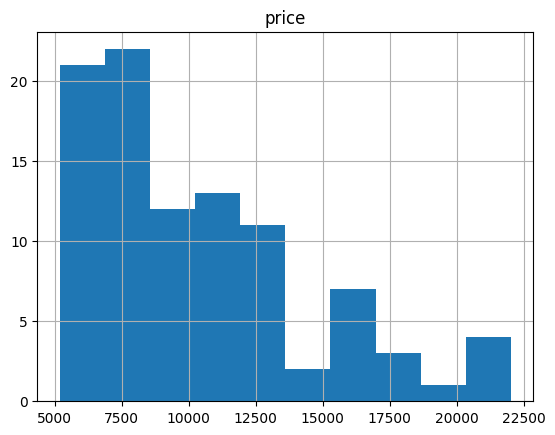

In [150]:
y_train.hist()

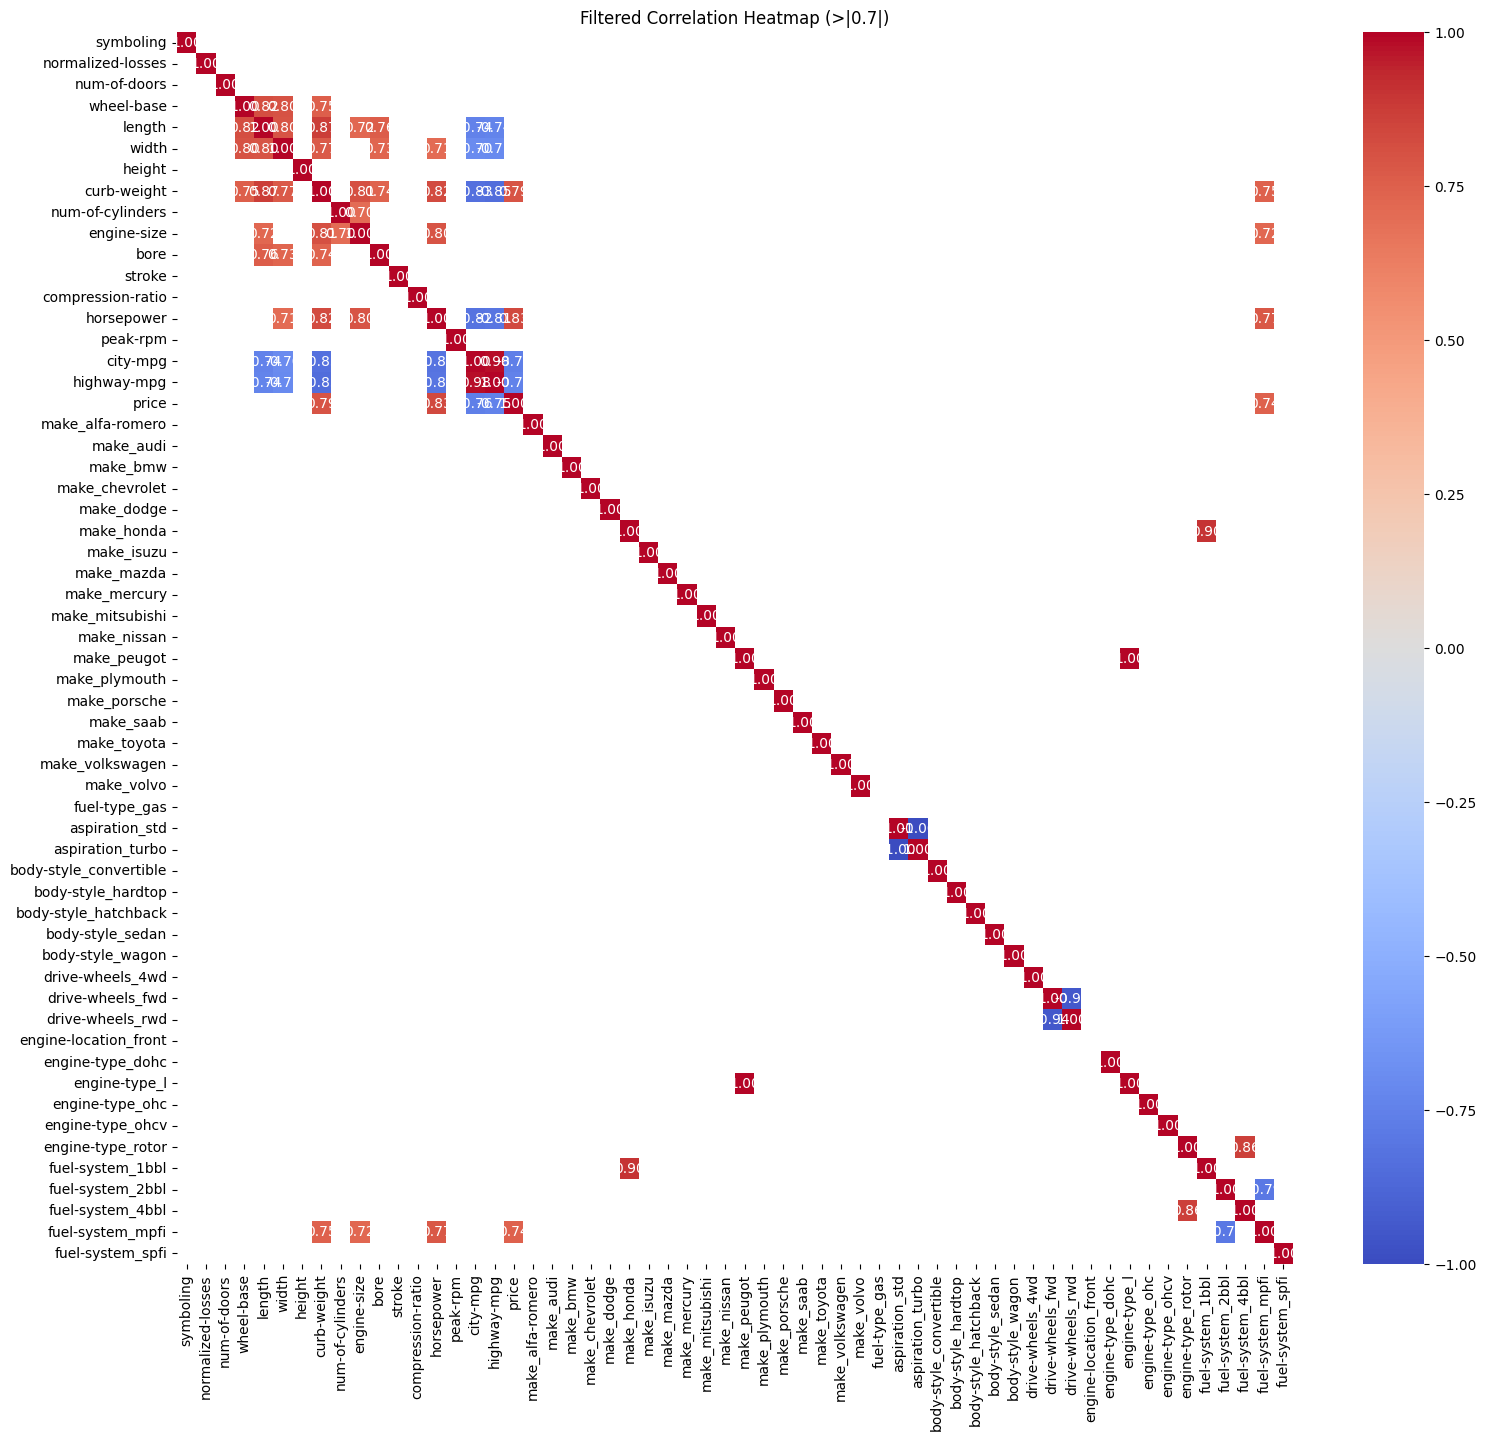

In [167]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.corr()
mask = np.abs(corr_matrix) < 0.7  # Hide weak correlations
plt.figure(figsize=(18, 16))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Filtered Correlation Heatmap (>|0.7|)")
plt.show()


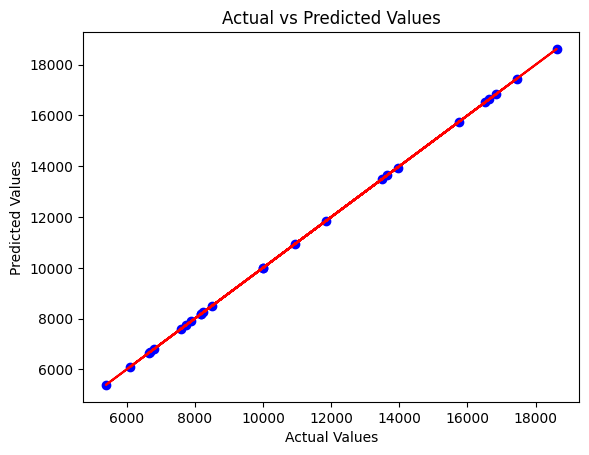

In [161]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred, color='blue')
plt.plot(y_test, y_test, color='red')  # Perfect prediction line
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()


In [168]:
import pandas as pd

# Assuming df is your dataset with features and target
correlation_matrix = df.corr()

# Sort correlation of all features with the target column
target_corr = correlation_matrix["price"].sort_values(ascending=False)

print(target_corr)


price                     1.000000
horsepower                0.829450
curb-weight               0.790181
fuel-system_mpfi          0.744541
engine-size               0.692237
width                     0.686883
length                    0.665043
bore                      0.655268
drive-wheels_rwd          0.585868
wheel-base                0.570941
make_volvo                0.365812
aspiration_turbo          0.338888
num-of-cylinders          0.333653
make_bmw                  0.330295
engine-type_dohc          0.324128
engine-type_ohcv          0.269965
make_porsche              0.254213
make_saab                 0.239033
make_audi                 0.194755
normalized-losses         0.193108
body-style_convertible    0.192984
make_alfa-romero          0.192764
body-style_sedan          0.171535
height                    0.163064
make_mercury              0.132528
engine-type_l             0.121788
make_peugot               0.121788
engine-type_rotor         0.112775
num-of-doors        

In [170]:
df.eq(df['price'], axis=0).sum().sort_values(ascending=False)

,0
price,121
symboling,0
body-style_wagon,0
make_saab,0
make_toyota,0
make_volkswagen,0
make_volvo,0
fuel-type_gas,0
aspiration_std,0
aspiration_turbo,0


In [173]:
df_scaled = df.copy()

# Select only numeric features for scaling
numeric_features = df_scaled.select_dtypes(include=['number']).columns
df_scaled[numeric_features] = (df_scaled[numeric_features] - df_scaled[numeric_features].min()) / (df_scaled[numeric_features].max() - df_scaled[numeric_features].min())

df_scaled.eq(df_scaled["price"], axis=0).sum().sort_values(ascending=False)

,0
price,121
fuel-system_mpfi,2
make_porsche,2
drive-wheels_rwd,2
symboling,1
body-style_hatchback,1
make_saab,1
make_toyota,1
make_volkswagen,1
make_volvo,1


In [182]:
features_to_drop = ['horsepower', 'curb-weight', 'fuel-system_mpfi']
df_new = df.drop(columns=features_to_drop)


In [195]:
X = df_new.drop(columns=['price'])
y = df_new['price']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1000)

# Train the model
# model = LinearRegression()
model= DecisionTreeRegressor()

model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)
y_pred_tr = model.predict(X_train)

In [196]:
print("After dropping features:")
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 score:", r2_score(y_test, y_pred))

After dropping features:
MSE: 4325653.04
R2 score: 0.739567206498063


In [197]:
print("After dropping features:")
print("MSE:", mean_squared_error(y_train, y_pred_tr))
print("R2 score:", r2_score(y_train, y_pred_tr))

After dropping features:
MSE: 218065.87152777775
R2 score: 0.9873093171413565
